In [ ]:
# RUN IMPORT LIBRARIES
############################################################################################
import numpy as np
import scipy
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import cv2
import tifffile as tiff
# from PIL import Image
import h5py
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max

import scipy as sc

import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.FRC_lib as frc
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.analysis.FocusISM_lib as fism
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.Tools_lib as tool
import brighteyes_ism.dataio.mcs as mcs
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.simulation.PSF_sim as sim
# from scipy.ndimage import fourier_shift, shift 
from os import path
import plotly.express as px
from time import time

In [2]:
file = 'Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7'

# Qdots_37mW_FOV5um_64x64_100rip_5msPixel # fototubo?
# Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8
# Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7
# Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5
# Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4
# Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6

In [3]:
# RUN INPUT
#############################################################################################

#############################################################################################
# FILE IMPORT AND SETUP
############################################################################################

dir = os.getcwd()
filename = path.join(dir,'images','2025 07 07-08 Qdots',file) # input
savename = path.join(dir,'images','output',file) # output
savenameSOFI = path.join(dir,'images','output','SOFI',file)

timeSwitch = True #True if i saved the timetraces
spadFormat=7
Nspad = spadFormat**2

index7=[i for i in range(49) if i != 12]
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]


f = h5py.File(filename + '.h5', 'r') # read h5 file

# ----------------- read header

if timeSwitch:
    group = f['Fluctuations']
    print('Opening time data...')
    Endoftime_h5 = group['IsEndOfTimeBin'][()]
    t_bin=group['Time'][()][0]/1000        #micros
    rep = group.attrs['I_Repetitions'][0]      #repetitions  
else:
    group = f['Image']

imgFormat=group.attrs['I_Height'][0]       #pixels
Depth=group.attrs['I_Depth'][0]            #repetitions/z
ImgFoV=group.attrs['I_XSpan[um]'][0]       #micron
pxsizex=group.attrs['I_XPixelSize[nm]'][0]/1000 #micron         
ZSpan=group.attrs['I_ZSpan[um]'][0]        #micron
pxsizez=group.attrs['I_ZPixelSize[nm]'][0]/1000 #micron
Duration=group.attrs['M_Duration[ms]'][0]  #ms
DwellTime=Duration/(Depth*imgFormat**2)    #ms (approximate)
Fingerprint_h5 = group['Fingerprint'][()]

# ---------------- reading SPAD DATA

print('Opening SPAD data...')
data_h5= group['SPAD'][()]
print('Finished opening')
f.close()

# ----------------- display metadata

print('--------------------METADATA:--------------')
print('imgFormat: ',imgFormat,'x',imgFormat,'px')
print('depth (z): ', Depth)
print('FOV: ', ImgFoV,'μm')
print('pixelsize (x-y): ', pxsizex,'μm')
print('pixelsize (z): ', pxsizez,'μm')
print('ZSpan (z-range):', ZSpan,'μm')
print('Duration frame:', Duration,'ms')
print('Dwell time (time per pixel):', DwellTime,'ms')
print('---------------------------------------------')

# ---------------- fixing binning

# Ch,T,X,Y,R,Z
# print('Full data size: ' + str(data_h5.shape[0]))
# print('Total time bins (no channel distinction): ' +str(Endoftime_h5.shape[0]))

endtime=np.asarray(np.where(Endoftime_h5==1))[0,:]       #Cerco gli indici di Endoftime_h5 dove finiscono i pixels
# print('Scan pixels: ' + str(endtime.shape[0]))
# print('\nendtime: '+str(endtime[:10]))
v = np.max(np.diff(endtime))                             #Cerco la durata massima
# print('maximum temporal timetrace length: ' +str(v))                  
overflow = endtime[np.asarray(np.where(np.diff(endtime)==v))[0,:]+1]  #Indici di cut degli elementi in overflow
# print('\nOverflow: ' +str(overflow))
# print('Pixels in overflow: ' + str(overflow.shape[0]))

over_del = np.zeros(((overflow.shape[0]+1)*Nspad)).astype(np.int64)
for j in range(Nspad):
    over_del[(j)*overflow.shape[0]:overflow.shape[0]*(j+1)]= ((overflow*Nspad)+j)

g=np.linspace(0,48,49).astype(int)
if endtime[0]+1==v: 
    over_del[-49:]=((endtime[0]*Nspad)+g)
else:
    over_del=np.delete(over_del, np.linspace(over_del.shape[0]-Nspad, over_del.shape[0]-1).astype(int) , axis=(0))
    
# print('Bin in data_h5 to be removed: ' +str(over_del))

data_crop = np.delete(data_h5, over_del)
del over_del
del endtime
del g
del overflow
# print('\nFinal size of cropped data: ' +str(data_crop.shape[0]))
# print('Expected size: ' +str(Nspad*Depth*rep*imgFormat**2*(v-1)))

if not data_crop.shape[0]==Nspad*Depth*rep*imgFormat**2*(v-1):
    raise 'data error, bin not corresponding'
# print('size cropped == expected size: ', str(data_crop.shape[0]==Nspad*Depth*rep*imgFormat**2*(v-1)))

# ---------------------------- reshaping (z,rep,y,x,y,ch)

z_i, rep_i, y_i, x_i, t_i, ch_i = 0, 1, 2, 3, 4, 5 # indexes of reshaped data

fingerprint_meta = np.reshape(Fingerprint_h5, (spadFormat,spadFormat))
if not timeSwitch:
    data=np.reshape(data_h5,(Depth,1,imgFormat,imgFormat,1,Nspad)) 
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
else:
    data=np.reshape(data_crop, (Depth,rep,imgFormat,imgFormat,v-1,Nspad))
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
    del data_crop
   
# print('\nCumulative Dwell time (approx.): ' + str(DwellTime) +' ms')
# print('FoV [um]: ' + str(ImgFoV))
# if timeSwitch: print('Time binsize [us]: ' +str(t_bin))
# print('Pixel size [um]: ' +str(pxsizex))
del data_h5 # free the memory

#############################################################################################
# FIRST PLOT, all the data is in 'data'
############################################################################################


CENTRAL_SPAD = data[0, :, :, :, :, 24].sum(axis=(3, 0)).astype(np.uint8)
COFOCAL = data[0, :, :, :, :, :].sum(axis=(3, 0, 4)).astype(np.uint8)

# im = Image.fromarray(CENTRAL_SPAD) # convert to an image

# -------------------- Plot with Plotly

fig = px.imshow(
    CENTRAL_SPAD, 
    color_continuous_scale='hot',
    title='CENTRAL SPAD',
)
fig.update_layout(
    margin=dict(l=30, r=0, t=0, b=0),
    width=400,
    height=400,
    title=dict(
        y=0.95,  # move title closer to plot
        x=0.5,   # keep centered
        xanchor='center',
        yanchor='top'
    )
)

fig.show()

del Endoftime_h5

Opening time data...
Opening SPAD data...
Finished opening
--------------------METADATA:--------------
imgFormat:  32 x 32 px
depth (z):  1
FOV:  3.0 μm
pixelsize (x-y):  0.09375 μm
pixelsize (z):  100.0 μm
ZSpan (z-range): 100.0 μm
Duration frame: 264001.77664 ms
Dwell time (time per pixel): 257.814235 ms
---------------------------------------------
Data format (z,rep,y,x,t,ch) (1, 50, 32, 32, 50, 49)


### RIASSUNTO METADATA:

| **Parameter** | **Description**                             | **Unit**        |
|---------------|---------------------------------------------|-----------------|
| `imgFormat`   | Image format (e.g., 512x512)                | pixels          |
| `Depth`       | Repetitions along the Z-axis                | repetitions / z |
| `ImgFoV`      | Field of view                               | micron          |
| `pxsizex`     | Pixel size (X/Y axis)                       | micron          |
| `ZSpan`       | Z-axis span (total depth range)             | micron          |
| `pxsizez`     | Pixel size along Z-axis                     | micron          |
| `Duration`    | Time per pixel (e.g., 500 µs)               | ms              |
| `DwellTime`   | Minimum time unit (approximate)             | ms              |


# SELECTOR

data is in the format (z,rep,y,x,t,ch), for speeding up we work with d1,d3,d5,d7
the following code select the data:

- SINGLE REPETITION: select a single repetition giving (y,x,t,ch)
- SUM OVER REPETITION: the signal of each repetition is summed, that way the value of timetracks increase (y,x,t,ch)
- SUM OVER REPETITION AND TIME: is a static image with no time traces like a normal cofocal (x,y,ch)
- CONCATENATE REPETITION: the total time track is the concatenation of each rep timetrack (x,y,t,ch)

In [ ]:
# DON'T RUN SELECTOR
# (z,rep,y,x,t,ch)

##########################################################################################################
#                         SELECT A SINGLE REPETITION (y,x,t,ch) of 1 rep
#########################################################################################################
# REPETITION_TO_SELECT_D3 = 10 
# REPETITION_TO_SELECT_D5 = 0

# d3=np.asarray([data[0,REPETITION_TO_SELECT_D3,:,:,:,i] for i in index3], dtype='float') # -> outputshape (ch,y,x,t)
# d3=np.transpose(d3,(1,2,3,0))
# print('d3 format (y,x,t,ch): ' +str(d3.shape))

# d5=np.asarray([data[0,REPETITION_TO_SELECT_D5,:,:,:,i] for i in index5], dtype='float') # -> outputshape (ch,y,x,t)
# d5=np.transpose(d5,(1,2,3,0))
# print('d5 format (y,x,t,ch): ' +str(d5.shape))

# d7 = np.asarray([data[0,REPETITION_TO_SELECT_D5,:,:,:,i] for i in index7], dtype='float') # -> outputshape (ch,y,x,t)
# d7=np.transpose(d7,(1,2,3,0))
# print('d7 format (y,x,t,ch): ' +str(d7.shape))


##########################################################################################################
#                         SUM OVER REPETITION (y,x,t,ch) summed rep
#########################################################################################################

# d3=np.asarray([data[0,:,:,:,:,i] for i in index3], dtype='float') # -> outputshape (ch,rep,y,x,t)
# d3=np.sum(d3,axis=1)
# d3=np.transpose(np.asarray(d3),(1,2,3,0))
# print('d3 format (y,x,t,ch): ' +str(d3.shape))

# d5=np.asarray([data[0,:,:,:,:,i] for i in index5], dtype='float') # -> outputshape (ch,rep,y,x,t)
# d5=np.sum(d5,axis=1)
# d5=np.transpose(np.asarray(d5),(1,2,3,0))
# print('d5 format (y,x,t,ch): ' +str(d5.shape))

# d7 = np.asarray([data[0,:,:,:,:,i] for i in index7], dtype='float') # -> outputshape (ch,rep,y,x,t)
# d7=np.sum(d7,axis=1)
# d7=np.transpose(np.asarray(d7),(1,2,3,0))
# print('d7 format (y,x,t,ch): ' +str(d7.shape))

#---------------------
# shows how the signal increase if summed all events for every repetition

# pixelx,pixely = 21,10 # signal
# pixelx1,pixely1 = 30,59 #bkg
# plt.plot(d3[pixely,pixelx,:,4],label='signal')
# plt.plot(d3[pixely1,pixelx1,:,4],label='bkg')
# plt.xlabel('Time ticks')
# plt.xticks(np.arange(0, d3.shape[2]))
# plt.ylabel('Intensity')
# plt.title('Signal vs Background in center image')
# plt.legend()
# plt.show()

#----------------------
#Save central element time series (over all repetitions summed) as stack

# full_path = savename + ' central timetrace sumrep.tiff'
# tifffile.imwrite(full_path, np.transpose(d3[:,:,:,4], (2,0,1)))
# display(HTML(f'<a href="file://{full_path}" target="_blank">{full_path}</a>'))

##########################################################################################################
#                         SUM OVER REPETITION and TIME (y,x,ch)
#########################################################################################################

# d3=np.asarray([data[0,:,:,:,:,i] for i in index3], dtype='float') # output -> (ch,rep,y,x,t)
# d3=np.sum(d3,axis=(1,4))
# d3=np.transpose(np.asarray(d3),(1,2,0))
# print('d3 format (y,x,ch): ' +str(d3.shape))

# d5=np.asarray([data[0,:,:,:,:,i] for i in index5], dtype='float') # output -> (ch,rep,y,x,t)
# d5=np.sum(d5,axis=(1,4))
# d5=np.transpose(np.asarray(d5),(1,2,0))
# print('d5 format (y,x,ch): ' +str(d5.shape))

# d7=np.asarray([data[0,:,:,:,:,i] for i in index7], dtype='float') # output -> (ch,rep,y,x,t)
# d7=np.sum(d7,axis=(1,4))
# d7=np.transpose(np.asarray(d7),(1,2,0))
# print('d7 format (y,x,ch): ' +str(d7.shape))

#-------------------------------------
# save central confocal image

# full_path = savename + ' central confocal.tiff'

# img = Image.fromarray(d3[:,:,4].astype(np.uint8))
# img.save(full_path)

# display(HTML(f'<a href="file://{full_path}" target="_blank">{full_path}</a>'))

##########################################################################################################
#                         CONCATENATE REP TIME (y,x,t*rep,ch)
#########################################################################################################

# d3= np.asarray([data[0,:,:,:,:,i] for i in index3], dtype='float') # -> output (ch,rep,y,x,t)
# data_transposed = np.transpose(d3, (2, 3, 1, 4, 0))  # (ch, y, x, rep, t)
# y, x, rep, t, ch = data_transposed.shape
# d3 = data_transposed.reshape(y, x, rep * t, ch)
# print('d3 format (y,x,t*rep, ch): ' +str(d3.shape))

# d5 = np.asarray([data[0,:,:,:,:,i] for i in index5], dtype='float') # -> output (ch,rep,y,x,t)
# data_transposed = np.transpose(d5, (2, 3, 1, 4, 0))  # (ch, y, x, rep, t)
# y, x, rep, t, ch = data_transposed.shape
# d5 = data_transposed.reshape(y, x, rep * t, ch)
# print('d5 format (y,x,t*rep, ch): ' +str(d5.shape))

# d7 = np.asarray([data[0,:,:,:,:,i] for i in index7], dtype='float') # -> output (ch,rep,y,x,t)
# data_transposed = np.transpose(d7, (2, 3, 1, 4, 0))  # (ch, y, x, rep, t)
# y, x, rep, t, ch = data_transposed.shape
# d7 = data_transposed.reshape(y, x, rep * t, ch)
# print('d7 format (y,x,t*rep, ch): ' +str(d7.shape))

#------------------------------------
# plot signal
# pixelx,pixely = 21,10 # signal
# pixelx1,pixely1 = 30,59 #bkg

# plt.figure(figsize=(10, 4))
# plt.plot(d3[pixely,pixelx,:,4],label='signal')
# plt.plot(d3[pixely1,pixelx1,:,4],label='bkg')
# plt.xlabel('Time ticks')
# # plt.xticks(np.arange(0, d3.shape[2]))
# plt.ylabel('Intensity')
# plt.title('Signal vs Background in center image')

# plt.legend()
# plt.show()

# Image reconstruction (ISM)

The available d3s are: 

data [z,r,y,x,t,ch] <br> d3, d5, d1 [y,x,t,ch] <br>datacut [y,x,t,ch] (- spad 12)

|  0 |  1 |  2 |  3 |  4 |  5 |  6 |   →   |  0 |  1 |  2 |  3 |  4 |  5 |  6 |
|----|----|----|----|----|----|----|-------|----|----|----|----|----|----|----|
|  7 |  8 |  9 | 10 | 11 | 12 | 13 |       |  7 |  8 |  9 | 10 | 11 |  _ | 12 |
| 14 | 15 | 16 | 17 | 18 | 19 | 20 |       | 13 | 14 | 15 | 16 | 17 | 18 | 19 |
| 21 | 22 | 23 | 24 | 25 | 26 | 27 |       | 20 | 21 | 22 | 23 | 24 | 25 | 26 |
| 28 | 29 | 30 | 31 | 32 | 33 | 34 |       | 27 | 28 | 29 | 30 | 31 | 32 | 33 |
| 35 | 36 | 37 | 38 | 39 | 40 | 41 |       | 34 | 35 | 36 | 37 | 38 | 39 | 40 |
| 42 | 43 | 44 | 45 | 46 | 47 | 48 |       | 41 | 42 | 43 | 44 | 45 | 46 | 47 |

In [5]:
#############################################################################################
# data initialization
############################################################################################

index7_fix=[i for i in range(48)]
index5_fix=[8,9,10,11,14,15,16,17,18,21,22,23,24,25,28,29,30,31,32,35,36,37,38,39]
index3_fix=[15,16,17,22,23,24,29,30,31]
index1_fix=[16,22,23,24,30]

# datacut = d7 - spad12
datacut = np.sum(np.delete(data, 12,5)[0,:,:,:,:],axis=(0,3))[...] #Remove SPAD 12 -> output (y,x,ch)
d3 = datacut[:,:,index3_fix]
d5 = datacut[:,:,index5_fix]
d1 = datacut[:,:,index1_fix]
d7 = datacut[:,:,index7_fix]

c:\ProgramData\anaconda3\Lib\site-packages\brighteyes_ism\analysis\Graph_lib.py:550: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



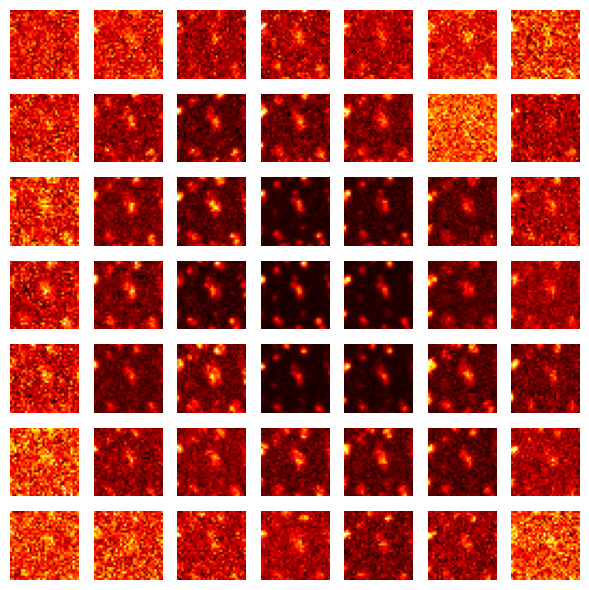

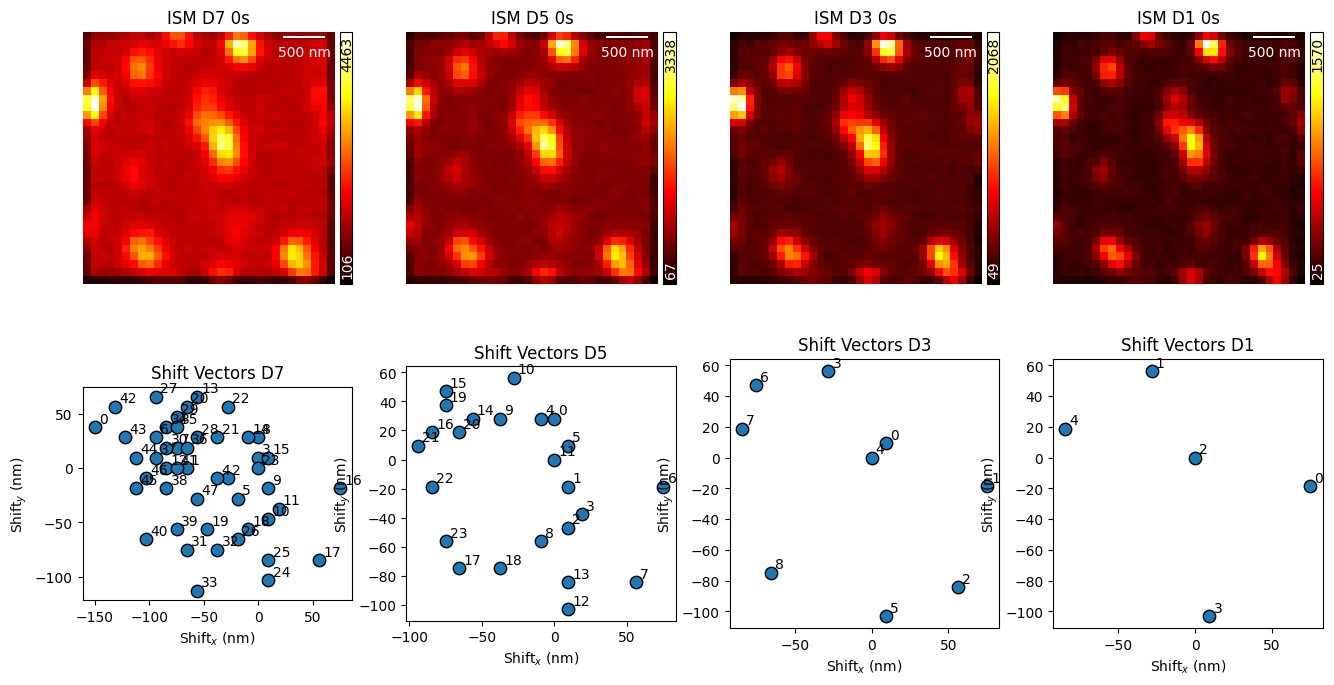

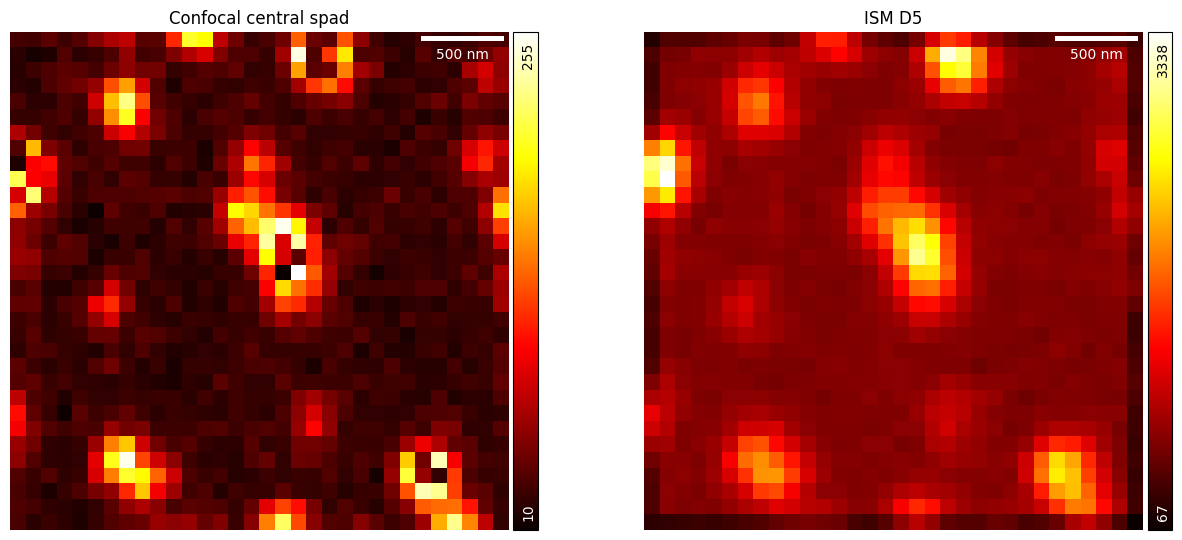

In [6]:
# RUN ISM
#############################################################################################
# CHECK FINGERPRINT
############################################################################################

fingerprint = tool.fingerprint(data.sum(axis=(0,1,4)))
fingerprint[1,5]=(fingerprint[1,4]+fingerprint[1,6])/2 #smooth spad 12
fingerprint_meta[1,5]=(fingerprint_meta[1,4]+fingerprint_meta[1,6])/2
c= int((spadFormat-1)/2)  #change it if the maximum is not at the center


for i in range(7):
    for j in range(7):
        if str(round(fingerprint[i,j]*100/fingerprint[c,c])) != str(round(fingerprint_meta[i,j]*100/fingerprint_meta[c,c])):
            raise 'fingerprint not matching'
        # ax[0].text(j-0.3,i, str(round(fingerprint[i,j]*100/fingerprint[c,c])) + '%', color='limegreen')
        # ax[0].set_title('Experimental fingerprint')
        # ax[1].text(j-0.3,i, str(round(fingerprint_meta[i,j]*100/fingerprint_meta[c,c])) + '%', color='limegreen')
        # ax[1].set_title('Software fingerprint')

fig_1 = gra.ShowDataset(np.sum(data,axis=(z_i,rep_i,t_i)),normalize = False, colorbar=False) # SHOW 49 images


#############################################################################################
# APR
############################################################################################

#ISM image
usf = 10  # upsampling factor = subpixel precision
ref_D5 = 11 # reference image to compute the shift vectors (center spad)
ref_D3 = 4  # reference image to compute the shift vectors (center spad)
ref_D7 = 23 # reference image to compute the shift vectors (center spad)
ref_D1 = 2 # reference image to compute the shift vectors (center spad)


start = time()
shift_vec7, ISM_D7_CH = apr.APR(d7, usf, ref_D7, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
ISM_D7 = ISM_D7_CH.sum(axis=2)
end = time()
TIME_ISM_D7 = end - start

start = time()
shift_vec5, ISM_D5_CH = apr.APR(d5, usf, ref_D5, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
ISM_D5 = ISM_D5_CH.sum(axis=2)
end = time()
TIME_ISM_D5 = end - start

start = time()
shift_vec3, ISM_D3_CH = apr.APR(d3, usf, ref_D3, filter_sigma=1, pxsize = pxsizex*1000)
ISM_D3 = ISM_D3_CH.sum(axis=2)
end = time()
TIME_ISM_D3 = end - start

start = time()
shift_vec1, ISM_D1_CH = apr.APR(d1, usf, ref_D1, filter_sigma=1, pxsize = pxsizex*1000)
ISM_D1 = ISM_D1_CH.sum(axis=2)
end = time()
TIME_ISM_D1 = end - start

fig, ax = plt.subplots(2, 4, figsize=(4*4,8))

gra.ShowImg(ISM_D7, pxsize_x = pxsizex, fig = fig, ax = ax[0,0])
ax[0,0].set_title('ISM D7 ' + str(int(TIME_ISM_D7)) + 's')
gra.PlotShiftVectors(shift_vec7, fig = fig, ax = ax[1,0])
ax[1,0].set_title('Shift Vectors D7')

gra.ShowImg(ISM_D5, pxsize_x = pxsizex, fig = fig, ax = ax[0,1])
ax[0,1].set_title('ISM D5 ' + str(int(TIME_ISM_D5)) + 's')
gra.PlotShiftVectors(shift_vec5, fig = fig, ax = ax[1,1])
ax[1,1].set_title('Shift Vectors D5')

gra.ShowImg(ISM_D3, pxsize_x = pxsizex, fig = fig, ax = ax[0,2])
ax[0,2].set_title('ISM D3 ' + str(int(TIME_ISM_D3)) + 's')
gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1,2])
ax[1,2].set_title('Shift Vectors D3')

gra.ShowImg(ISM_D1, pxsize_x = pxsizex, fig = fig, ax = ax[0,3])
ax[0,3].set_title('ISM D1 ' + str(int(TIME_ISM_D1)) + 's')
gra.PlotShiftVectors(shift_vec1, fig = fig, ax = ax[1,3])
ax[1,3].set_title('Shift Vectors D1')

plt.show()

#############################################################################################
# ISM VS SPAD
############################################################################################

fig, ax = plt.subplots(1, 2, figsize=(15,10))

gra.ShowImg(CENTRAL_SPAD[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[0]) #[422:512,45:135]
ax[0].set_title('Confocal central spad')

gra.ShowImg(ISM_D5[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[1]) #[320:356,206:242]
ax[1].set_title('ISM D5')
plt.show()

del d1,d3,d5,d7
del ISM_D1_CH, ISM_D3_CH, ISM_D5_CH, ISM_D7_CH
del shift_vec1, shift_vec3, shift_vec5, shift_vec7

# SOFI

3 kinds of way to sofi:

- SUM SOFI: sum the timetracks for each rep and autocorrelate
- CONCAT SOFI: concantenate timetracks for each rep and autocorrelate
- MEAN SOFI: autocorrelate for each rep and mean the correlation function

done SOFI MEAN:  5.132234811782837 s
done SOFI SUM:  0.1759190559387207 s
done SOFI CONCAT:  1.9387099742889404 s


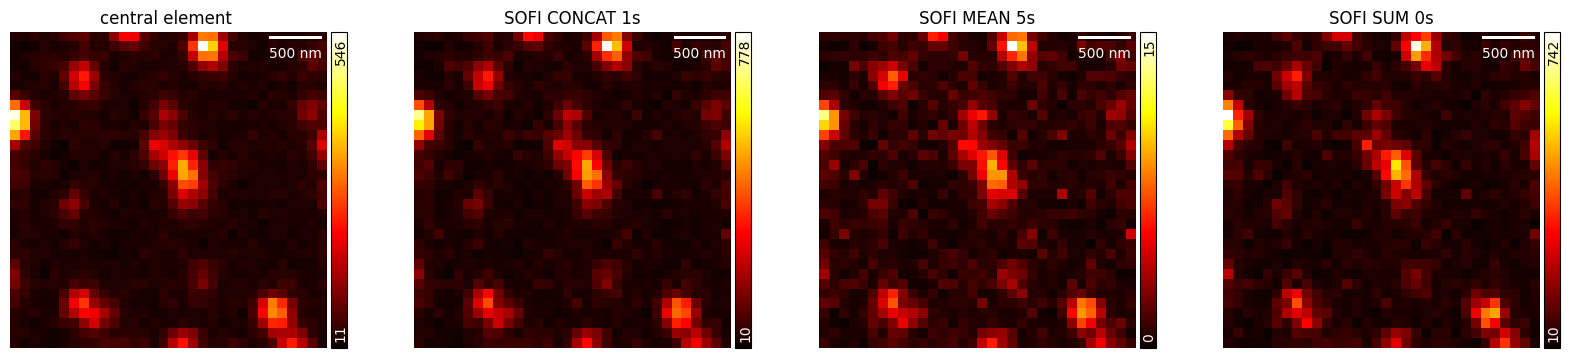

In [7]:
# RUN SOFI
###################################################################################################
#                         FUNCTION DEFINITIONS
##################################################################################################

def correlazione(t1,m1,t2,m2):
    fft1=scipy.fftpack.fft([(t1[i])-m1 for i in range(len(t1))])
    fft2=scipy.fftpack.fft([(t2[i])-m2 for i in range(len(t2))])
    fft1=np.ma.conjugate(fft1)
    crosscorr=np.real(scipy.fftpack.ifft(fft1*fft2))#/(m1*m2*len(t1)))
    return crosscorr

def autocorrelazione(t,m):
    return correlazione(t,m,t,m)  #autocorrelation is the correlation of a signal with itself


def SBR(img,xsi,xsf,xbi,xbf,ysi,ysf,ybi,ybf): # signal to backround ratio
    roi_s = img[xsi:xsf, ysi:ysf]
    roi_b = img[xbi:xbf, ybi:ybf]
    mean_roi_s = np.mean(roi_s)
    mean_roi_b = np.mean(roi_b)
    return mean_roi_s / mean_roi_b



central=np.asarray(data[0,:,:,:,:,24], dtype='float') # select central spad

rep_ic, y_ic, x_ic, t_ic = 0, 1, 2, 3 # indexes of central reshaped data

###################################################################################################
#                         SOFI MEAN
##################################################################################################

start = time()
SOFI_MEAN=np.zeros((central.shape[y_ic],central.shape[x_ic],central.shape[t_ic]), dtype=np.float64)
for i in range(central.shape[y_ic]):
    for j in range(central.shape[x_ic]):
        count=0
        for r in range(central.shape[rep_ic]):
            signal_mean = np.mean(central[r,i,j,:])
            if signal_mean != 0: # media sui tempi e skip dove bkg==0
                count += 1
                SOFI_MEAN[i,j,:] = SOFI_MEAN[i,j,:] + autocorrelazione(central[r,i,j,:],signal_mean)
        if count!=0:
            SOFI_MEAN[i,j,:] = SOFI_MEAN[i,j,:]/count

end = time()
TIME_SOFI_MEAN = end - start
print('done SOFI MEAN: ', TIME_SOFI_MEAN,'s')
# SOFI_MEAN_SBR = SBR(SOFI_MEAN[:,:,0], xsi,xsf,xbi,xbf,ysi,ysf,ybi,ybf)
# print('done SOFI MEAN - SBR: ', np.round(SOFI_MEAN_SBR,2))

###################################################################################################
#                         SOFI SUM
##################################################################################################

start = time()
central_repsum = central.sum(axis=rep_ic)  # Sum over repetitions
SOFI_SUM=np.zeros((central.shape[y_ic],central.shape[x_ic],central.shape[t_ic]), dtype=np.float64)
for i in range(central.shape[y_ic]):
    for j in range(central.shape[x_ic]):
        SOFI_SUM[i,j,:] = autocorrelazione(central_repsum[i,j,:],central_repsum[i,j,:].mean())

end = time()
TIME_SOFI_SUM = end - start
print('done SOFI SUM: ', TIME_SOFI_SUM,'s')
# SOFI_SUM_SBR = SBR(SOFI_SUM[:,:,0], xsi,xsf,xbi,xbf,ysi,ysf,ybi,ybf)
# print('done SOFI SUM - SBR: ', np.round(SOFI_SUM_SBR,2))

###################################################################################################
#                         SOFI CONCAT
##################################################################################################

start = time()
central_concat = np.transpose(central,(1,2,0,3)).reshape(central.shape[y_ic], central.shape[x_ic], -1)  # (y,x,t*rep)

SOFI_CONCAT=np.zeros((central.shape[y_ic],central.shape[x_ic],central.shape[t_ic]*central.shape[rep_ic]), dtype=np.float64)
for i in range(central.shape[y_ic]):
    for j in range(central.shape[x_ic]):
        # concateno su tutte le rep
        # plt.plot(central_concat)
        signal_mean = central_concat[i,j,:].mean()
        SOFI_CONCAT[i,j,:] = autocorrelazione(central_concat[i,j,:], signal_mean)

end = time()
TIME_SOFI_CONCAT = end - start
print('done SOFI CONCAT: ', TIME_SOFI_CONCAT,'s')
# SOFI_CONCAT_SBR = SBR(SOFI_CONCAT[:,:,0], xsi,xsf,xbi,xbf,ysi,ysf,ybi,ybf)
# print('done SOFI CONCAT - SBR: ', np.round(SOFI_CONCAT_SBR,2))

###################################################################################################
#                         SOFI SHOW
##################################################################################################

fig, ax = plt.subplots(1, 4, figsize=(20,5))
gra.ShowImg(np.sum(central,axis=(rep_ic,t_ic)), pxsize_x = pxsizex, fig = fig, ax = ax[0]) #[422:512,45:135]
ax[0].set_title('central element ')
gra.ShowImg(SOFI_CONCAT[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[1]) #[320:356,206:242]
ax[1].set_title('SOFI CONCAT ' + str(int(TIME_SOFI_CONCAT)) + 's')
gra.ShowImg(SOFI_MEAN[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[2]) #[320:356,206:242]
ax[2].set_title('SOFI MEAN ' + str(int(TIME_SOFI_MEAN)) + 's')
gra.ShowImg(SOFI_SUM[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[3]) #[320:356,206:242]
ax[3].set_title('SOFI SUM ' + str(int(TIME_SOFI_SUM)) + 's')
plt.show()

del central,central_concat, central_repsum

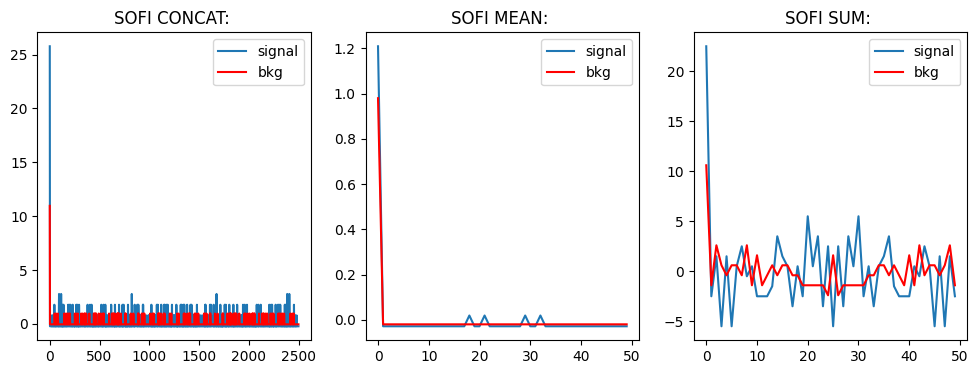

In [8]:
# CORRELATION FUNCTION ANALYSIS
#########################################################################

pixelx, pixely = 12, 17 # pixel coordinates of signal pixel
bkgx, bkgy = 5,11  # pixel coordinates of background pixels

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].plot(SOFI_CONCAT[pixely,pixelx, :], label='signal')
axes[0].plot(SOFI_CONCAT[bkgy,bkgx, :], 'r',label='bkg')
axes[0].set_title("SOFI CONCAT: ")
# axes[0].set_xlim((0,10))
#axes[0].set_xticks(np.arange(0, 9, 2))

axes[1].plot(SOFI_MEAN[pixely,pixelx, :], label='signal')
axes[1].plot(SOFI_MEAN[bkgy,bkgx, :], 'r',label='bkg')
axes[1].set_title("SOFI MEAN: " )

axes[2].plot(SOFI_SUM[pixely,pixelx, :], label='signal')
axes[2].plot(SOFI_SUM[bkgy,bkgx, :], 'r',label='bkg')
axes[2].set_title("SOFI SUM: ")

# plt.tight_layout()
axes[0].legend()
axes[1].legend()
axes[2].legend()
plt.show()


# COMPARISON SOFI VS ISM

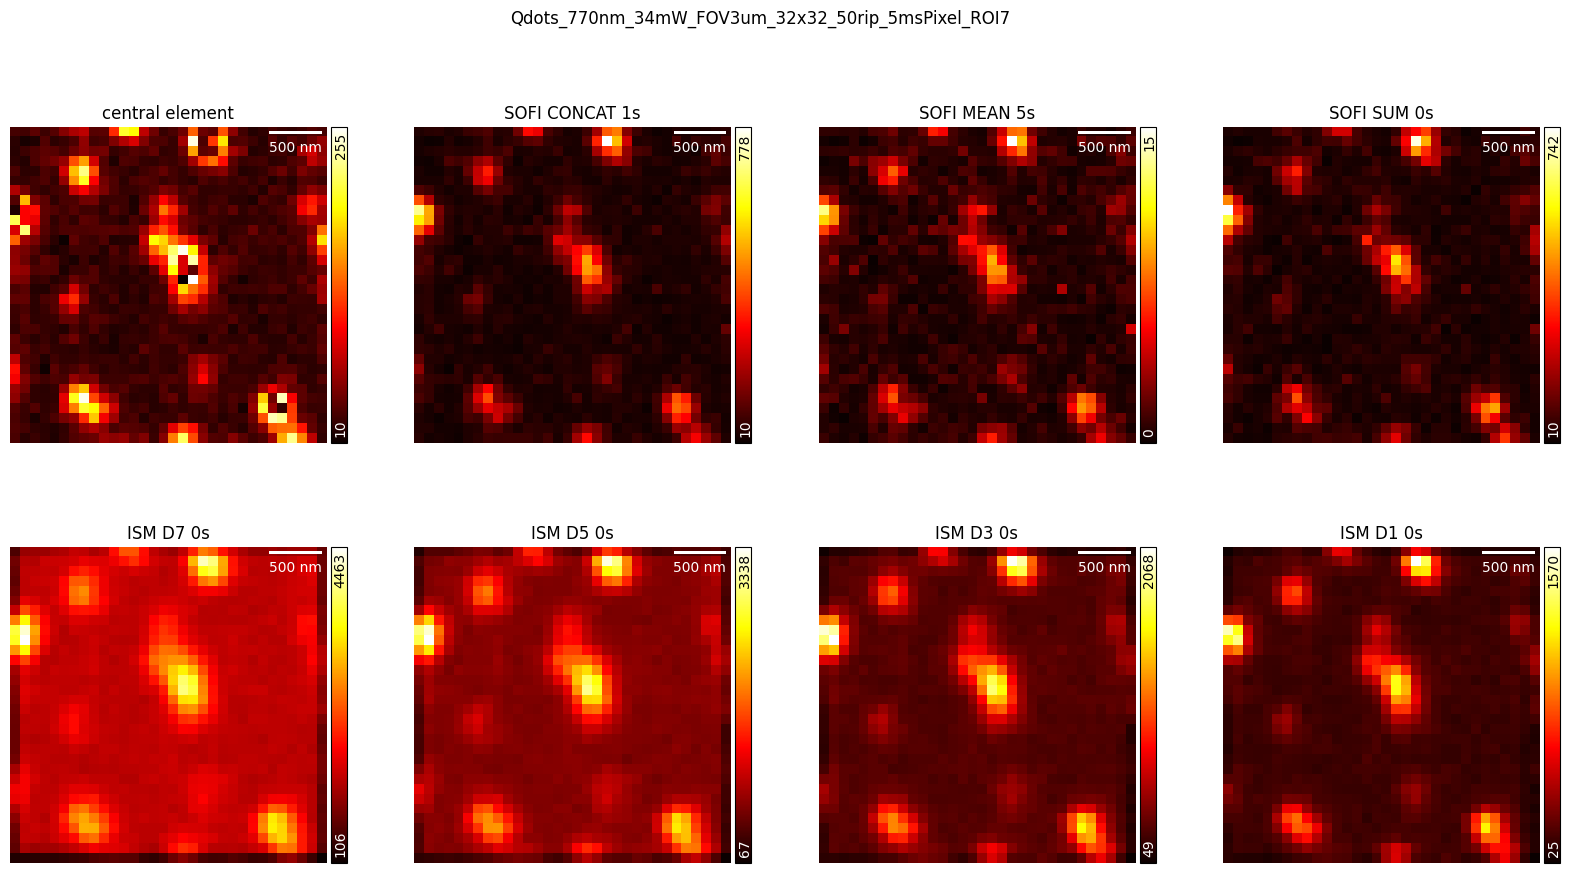

In [9]:
# SOFI VS ISM
fig, ax = plt.subplots(2, 4, figsize=(5*4,10))
gra.ShowImg(CENTRAL_SPAD, pxsize_x = pxsizex, fig = fig, ax = ax[0,0])
ax[0,0].set_title('central element')
gra.ShowImg(SOFI_CONCAT[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[0,1])
ax[0,1].set_title('SOFI CONCAT ' + str(int(TIME_SOFI_CONCAT)) + 's')
gra.ShowImg(SOFI_MEAN[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[0,2])
ax[0,2].set_title('SOFI MEAN ' + str(int(TIME_SOFI_MEAN)) + 's')
gra.ShowImg(SOFI_SUM[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[0,3])
ax[0,3].set_title('SOFI SUM ' + str(int(TIME_SOFI_SUM)) + 's')

gra.ShowImg(ISM_D7, pxsize_x = pxsizex, fig = fig, ax = ax[1,0])
ax[1,0].set_title('ISM D7 ' + str(int(TIME_ISM_D7)) + 's')

gra.ShowImg(ISM_D5, pxsize_x = pxsizex, fig = fig, ax = ax[1,1])
ax[1,1].set_title('ISM D5 ' + str(int(TIME_ISM_D5)) + 's')

gra.ShowImg(ISM_D3, pxsize_x = pxsizex, fig = fig, ax = ax[1,2])
ax[1,2].set_title('ISM D3 ' + str(int(TIME_ISM_D3)) + 's')

gra.ShowImg(ISM_D1, pxsize_x = pxsizex, fig = fig, ax = ax[1,3])
ax[1,3].set_title('ISM D1 ' + str(int(TIME_ISM_D1)) + 's')

fig.suptitle(file)
save_comparison = path.join(dir,'images','output','COMPARISON',file + '_comparison.png')
# fig.savefig(save_comparison)
plt.show()


# SOFISM

In [10]:
def batched_fft_correlate(sig1, sig2):
        """
        sig1, sig2: shape (ny, nx, nt)
        Returns correlation with shape (ny, nx, nt)
        mode='same' behavior
        """
        ny, nx, nt = sig1.shape
        # FFT length for 'same' mode
        nfft = nt
        f1 = np.fft.fft(sig1.reshape(-1, nt), n=nfft, axis=1)
        f2 = np.fft.fft(sig2.reshape(-1, nt), n=nfft, axis=1)
        corr = np.fft.ifft(f1 * np.conj(f2), axis=1).real
        # Shift so that center aligns like mode='same'
        corr = np.fft.fftshift(corr, axes=1)
        return corr.reshape(ny, nx, nt)

working on SOFISM d1... 
dataset D1 shape:  (32, 32, 2500, 5)
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 
done SOFISM D1: 0m3s


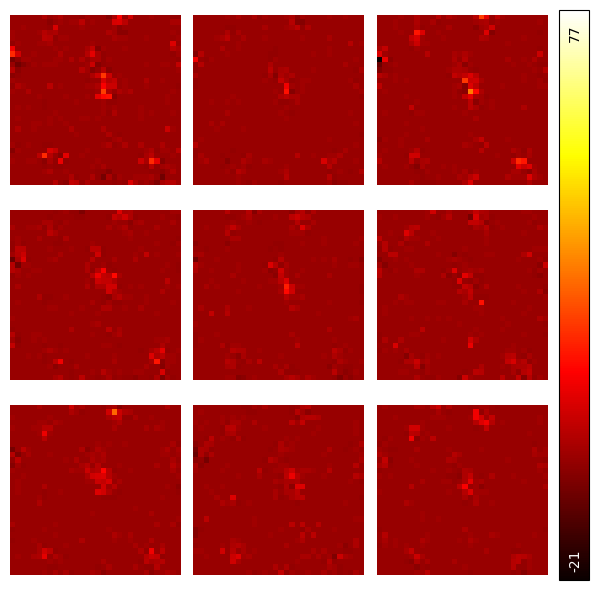

In [11]:
print('working on SOFISM d1... ')
start = time()
d1=np.asarray([data[0,:,:,:,:,i] for i in index1], dtype='float') # (z,rep,y,x,t,ch) -> (ch,rep,y,x,t)
d1=np.transpose(d1,(2,3,4,1,0)) # (ch,rep,y,x,t) -> (y,x,t,rep,ch)

d1 = d1.reshape(d1.shape[0],d1.shape[1],d1.shape[2]*d1.shape[3],d1.shape[4]) # (y,x,t,rep,ch) ->  (y,x,t*rep,ch)

ny, nx, nt, nch = d1.shape
imgN = int(nch * (nch + 1) / 2)
print('dataset D1 shape: ',d1.shape)

SOFISM_CORRELATION_0_d1 = np.zeros((ny, nx, imgN), dtype=np.int16)

    # Precompute mean-subtracted signals for all channels
d1_centered = d1 - d1.mean(axis=2, keepdims=True)

chindex=-1

import scipy as sc

for ch1 in range(nch):
    sig1 = d1_centered[:, :, :, ch1]  # shape (ny, nx, nt)
    for ch2 in range(ch1, nch, 1):
        chindex += 1
        print(chindex, end=' ')
        sig2 = d1_centered[:, :, :, ch2]
        # corr = batched_fft_correlate(sig1, sig2)
        SOFISM_CORRELATION_0_d1[:, :, chindex] = np.int16(batched_fft_correlate(sig1, sig2)[:,:,0])  # take only the first time point

usf = 10  # upsampling factor = subpixel precision
ref_d1 = 5+4

shift_vec_D1, SOFISM_D1_CH = apr.APR( SOFISM_CORRELATION_0_d1, usf, ref_d1, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
SOFISM_D1 = SOFISM_D1_CH.sum(axis=2)

end = time()
TIME_SOFISM_D1 = end - start

print('\ndone SOFISM D1: ' + str(int(TIME_SOFISM_D1/60)) + 'm' + str(int(TIME_SOFISM_D1%60)) + 's')
fig_1 = gra.ShowDataset(SOFISM_CORRELATION_0_d1,normalize = True, colorbar=True) # SHOW 49 images

del SOFISM_D1_CH, shift_vec_D1, SOFISM_CORRELATION_0_d1

In [12]:
print('working on SOFISM D3... ')
start = time()
d3=np.asarray([data[0,:,:,:,:,i] for i in index3], dtype='float') # (z,rep,y,x,t,ch) -> (ch,rep,y,x,t)
d3=np.transpose(d3,(2,3,4,1,0)) # (ch,rep,y,x,t) -> (y,x,t,rep,ch)

d3 = d3.reshape(d3.shape[0],d3.shape[1],d3.shape[2]*d3.shape[3],d3.shape[4]) # (y,x,t,rep,ch) ->  (y,x,t*rep,ch)

ny, nx, nt, nch = d3.shape
imgN = int(nch * (nch + 1) / 2)
print('dataset D3 shape: ',d3.shape)

SOFISM_CORRELATION_0_d3 = np.zeros((ny, nx, imgN), dtype=np.int16)

    # Precompute mean-subtracted signals for all channels
d3_centered = d3 - d3.mean(axis=2, keepdims=True)

chindex=-1

import scipy as sc

for ch1 in range(nch):
    sig1 = d3_centered[:, :, :, ch1]  # shape (ny, nx, nt)
    for ch2 in range(ch1, nch, 1):
        chindex += 1
        print(chindex, end=' ')
        sig2 = d3_centered[:, :, :, ch2]
        # corr = batched_fft_correlate(sig1, sig2)
        SOFISM_CORRELATION_0_d3[:, :, chindex] = np.int16(batched_fft_correlate(sig1, sig2)[:,:,0])  # take only the first time point

usf = 10  # upsampling factor = subpixel precision
ref_d3 = 9+8+7+6

shift_vec_D3, SOFISM_D3_CH = apr.APR( SOFISM_CORRELATION_0_d3, usf, ref_d3, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
SOFISM_D3 = SOFISM_D3_CH.sum(axis=2)

end = time()
TIME_SOFISM_D3 = end - start

del SOFISM_D3_CH, shift_vec_D3, SOFISM_CORRELATION_0_d3

print('\ndone SOFISM D3: ' + str(int(TIME_SOFISM_D3/60)) + 'm' + str(int(TIME_SOFISM_D3%60)) + 's')

working on SOFISM D3... 
dataset D3 shape:  (32, 32, 2500, 9)
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 
done SOFISM D3: 0m8s


In [ ]:
print('working on SOFISM D5... ')
start = time()
d5=np.asarray([data[0,:,:,:,:,i] for i in index5], dtype='float') # (z,rep,y,x,t,ch) -> (ch,rep,y,x,t)
d5=np.transpose(d5,(2,3,4,1,0)) # (ch,rep,y,x,t) -> (y,x,t,rep,ch)

d5 = d5.reshape(d5.shape[0],d5.shape[1],d5.shape[2]*d5.shape[3],d5.shape[4]) # (y,x,t,rep,ch) ->  (y,x,t*rep,ch)

ny, nx, nt, nch = d5.shape
imgN = int(nch * (nch + 1) / 2)
print('dataset D5 shape: ',d5.shape)

SOFISM_CORRELATION_0_d5 = np.zeros((ny, nx, imgN), dtype=np.int16)

    # Precompute mean-subtracted signals for all channels
d5_centered = d5 - d5.mean(axis=2, keepdims=True)

chindex=-1

import scipy as sc

for ch1 in range(nch):
    sig1 = d5_centered[:, :, :, ch1]  # shape (ny, nx, nt)
    for ch2 in range(ch1, nch, 1):
        chindex += 1
        print(chindex, end=' ')
        print('\n',end='') if chindex % 100 == 0 and chindex != 0 else None
        sig2 = d5_centered[:, :, :, ch2]
        # corr = batched_fft_correlate(sig1, sig2)
        SOFISM_CORRELATION_0_d5[:, :, chindex] = np.int16(batched_fft_correlate(sig1, sig2)[:,:,0])  # take only the first time point

usf = 10  # upsampling factor = subpixel precision
ref_d5 = 25+24+23+22+21+20+19+18+17+16+15

shift_vec_D5, SOFISM_D5_CH = apr.APR( SOFISM_CORRELATION_0_d5, usf, ref_d5, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
SOFISM_D5 = SOFISM_D5_CH.sum(axis=2)

end = time()
TIME_SOFISM_D5 = end - start

del SOFISM_D5_CH, shift_vec_D5, SOFISM_CORRELATION_0_d5

print('\ndone SOFISM D5: ' + str(int(TIME_SOFISM_D5/60)) + 'm' + str(int(TIME_SOFISM_D5%60)) + 's')

In [ ]:
try:
    print('working on SOFISM D7... ')
    start = time()
    d7=np.asarray([data[0,:,:,:,:,i] for i in index7], dtype='float') # (z,rep,y,x,t,ch) -> (ch,rep,y,x,t)
    d7=np.transpose(d7,(2,3,4,1,0)) # (ch,rep,y,x,t) -> (y,x,t,rep,ch)

    d7 = d7.reshape(d7.shape[0],d7.shape[1],d7.shape[2]*d7.shape[3],d7.shape[4]) # (y,x,t,rep,ch) ->  (y,x,t*rep,ch)

    ny, nx, nt, nch = d7.shape
    imgN = int(nch * (nch + 1) / 2)
    print('dataset D7 shape: ', d7.shape)

    SOFISM_CORRELATION_0_d7 = np.zeros((ny, nx, imgN), dtype=np.int16)

        # Precompute mean-subtracted signals for all channels
    d7_centered = d7 - d7.mean(axis=2, keepdims=True)

    chindex=-1

    import scipy as sc

    for ch1 in range(nch):
        sig1 = d7_centered[:, :, :, ch1]  # shape (ny, nx, nt)
        for ch2 in range(ch1, nch, 1):
            chindex += 1
            print(chindex, end=' ')
            print('\n',end='') if chindex % 100 == 0 and chindex != 0 else None
            sig2 = d7_centered[:, :, :, ch2]
        # corr = batched_fft_correlate(sig1, sig2)
            SOFISM_CORRELATION_0_d7[:, :, chindex] = np.int16(batched_fft_correlate(sig1, sig2)[:,:,0])  # take only the first time point

    usf = 10  # upsampling factor = subpixel precision
    ref_d7 = 48+47+46+45+44+43+42+41+40+39+38+37+36+35+34+33+32+31+30+29+28+27+26

    shift_vec_D7, SOFISM_D7_CH = apr.APR( SOFISM_CORRELATION_0_d7, usf, ref_d7, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
    SOFISM_D7 = SOFISM_D7_CH.sum(axis=2)

    end = time()
    TIME_SOFISM_D7 = end - start

    del SOFISM_D7_CH, shift_vec_D7, SOFISM_CORRELATION_0_d7

    print('done SOFISM D7: ' + str(int(TIME_SOFISM_D7/60)) + 'm' + str(int(TIME_SOFISM_D7%60)) + 's')
except Exception as e:
    print(repr(e))

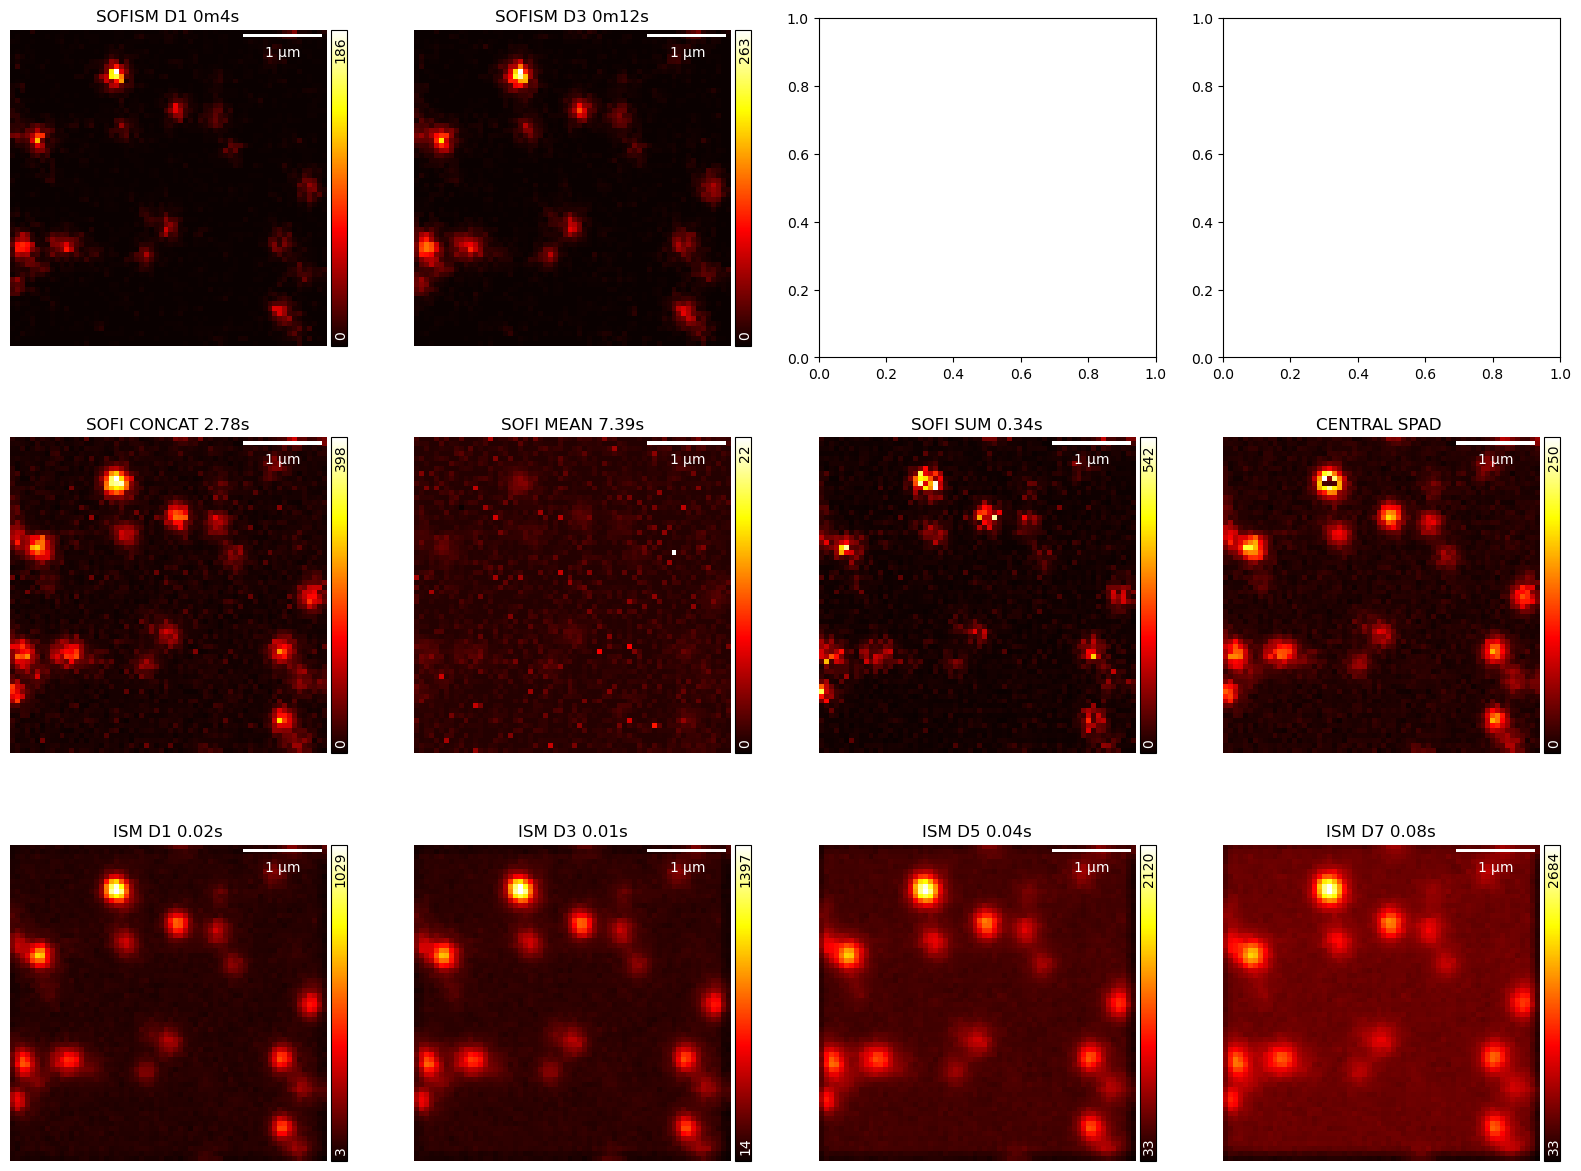

In [12]:
fig, ax = plt.subplots(3, 4, figsize=(5*4,15))

try:
    gra.ShowImg(SOFISM_D1, pxsize_x = pxsizex, fig = fig, ax = ax[0,0])
    ax[0,0].set_title('SOFISM D1 ' + str(int(TIME_SOFISM_D1/60)) + 'm' + str(int(TIME_SOFISM_D1%60)) + 's')

    gra.ShowImg(SOFISM_D3, pxsize_x = pxsizex, fig = fig, ax = ax[0,1])
    ax[0,1].set_title('SOFISM D3 ' + str(int(TIME_SOFISM_D3/60)) + 'm' + str(int(TIME_SOFISM_D3%60)) + 's')

    gra.ShowImg(SOFISM_D5, pxsize_x = pxsizex, fig = fig, ax = ax[0,2])
    ax[0,2].set_title('SOFISM D5 ' + str(int(TIME_SOFISM_D5/60)) + 'm' + str(int(TIME_SOFISM_D5%60)) + 's')


    gra.ShowImg(SOFISM_D7, pxsize_x = pxsizex, fig = fig, ax = ax[0,3])
    ax[0,3].set_title('SOFISM D7 ' + str(int(TIME_SOFISM_D7/60)) + 'm' + str(int(TIME_SOFISM_D7%60)) + 's')
except:
    pass

gra.ShowImg(SOFI_CONCAT[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[1,0])
ax[1,0].set_title('SOFI CONCAT ' + str(np.round(TIME_SOFI_CONCAT,2)) + 's')

gra.ShowImg(SOFI_MEAN[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[1,1])
ax[1,1].set_title('SOFI MEAN ' + str(np.round(TIME_SOFI_MEAN,2)) + 's')

gra.ShowImg(SOFI_SUM[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[1,2])
ax[1,2].set_title('SOFI SUM ' + str(np.round(TIME_SOFI_SUM,2)) + 's')

gra.ShowImg(CENTRAL_SPAD, pxsize_x = pxsizex, fig = fig, ax = ax[1,3])
ax[1,3].set_title('CENTRAL SPAD ')



gra.ShowImg(ISM_D1, pxsize_x = pxsizex, fig = fig, ax = ax[2,0])
ax[2,0].set_title('ISM D1 ' + str(np.round(TIME_ISM_D1,2)) + 's')

gra.ShowImg(ISM_D3, pxsize_x = pxsizex, fig = fig, ax = ax[2,1])
ax[2,1].set_title('ISM D3 ' + str(np.round(TIME_ISM_D3,2)) + 's')

gra.ShowImg(ISM_D5, pxsize_x = pxsizex, fig = fig, ax = ax[2,2])
ax[2,2].set_title('ISM D5 ' + str(np.round(TIME_ISM_D5,2)) + 's')

gra.ShowImg(ISM_D7, pxsize_x = pxsizex, fig = fig, ax = ax[2,3])
ax[2,3].set_title('ISM D7 ' + str(np.round(TIME_ISM_D7,2)) + 's')

plt.show()

# fig.savefig(path.join(dir,'images','output','COMPARISON',file + ' stack.tiff'), dpi=300)

In [ ]:
# SAVE ON FILE NORMALIZING from 0 to 1

CENTRAL_SPAD = np.array(CENTRAL_SPAD, dtype=np.float32)/np.max(CENTRAL_SPAD)
ISM_D1 = np.array(ISM_D1, dtype=np.float32)/np.max(ISM_D1)
ISM_D3 = np.array(ISM_D3, dtype=np.float32)/np.max(ISM_D3)
ISM_D5 = np.array(ISM_D5, dtype=np.float32)/np.max(ISM_D5)
ISM_D7 = np.array(ISM_D7, dtype=np.float32)/np.max(ISM_D7)
SOFI_CONCAT = np.array(SOFI_CONCAT[:,:,0], dtype=np.float32)/np.max(SOFI_CONCAT)
SOFI_MEAN = np.array(SOFI_MEAN[:,:,0], dtype=np.float32)/np.max(SOFI_MEAN)
SOFI_SUM = np.array(SOFI_SUM[:,:,0], dtype=np.float32)/np.max(SOFI_SUM)

try:
    SOFISM_D1 = np.array(SOFISM_D1, dtype=np.float32)/np.max(SOFISM_D1)
    SOFISM_D3 = np.array(SOFISM_D3, dtype=np.float32)/np.max(SOFISM_D3)
    SOFISM_D5 = np.array(SOFISM_D5, dtype=np.float32)/np.max(SOFISM_D5)
    SOFISM_D7 = np.array(SOFISM_D7, dtype=np.float32)/np.max(SOFISM_D7)
except Exception as e:
    pass

# SAVE 
try:
    # tiff.imwrite(path.join(dir,'images','output','COMPARISON',file + ' stack normalized.tiff'),
    #            [CENTRAL_SPAD, ISM_D1, ISM_D3, ISM_D5, ISM_D7, SOFI_CONCAT, SOFI_MEAN, SOFI_SUM, SOFISM_D1, SOFISM_D3, SOFISM_D5, SOFISM_D7])
    pass
except:
    pass

## Deconvolution

### Open experimental PSF

Open a tiff stack of the 49 PSFs and resize them to the same pixel size and number of pixels of the image

(512, 512, 49)


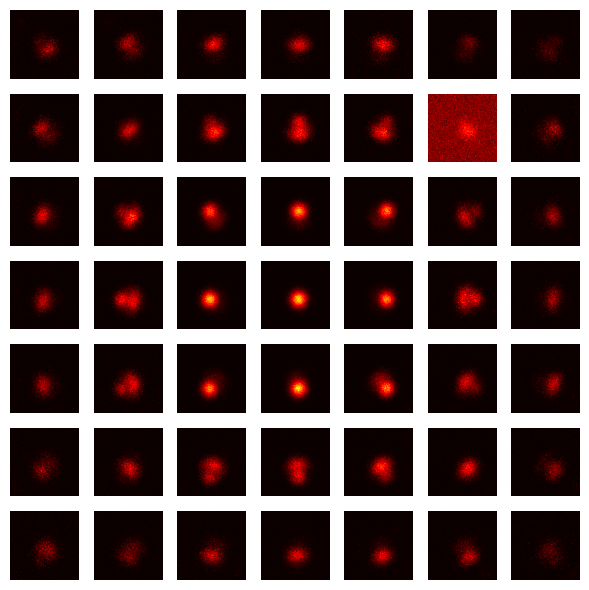

In [14]:
psf_exp = tiff.imread(path.join(dir,'images','170nm 5micron 220mW 50rep stack (PSF).tiff'))
psf_fov = 5 #micron
psf_format = 512
psf_exp =np.transpose(psf_exp, (1,2,0))
print(psf_exp.shape)
figx = gra.ShowDataset(psf_exp[160:360,160:360,:], normalize=False, colorbar=True)

In [15]:
psf_pxsize = psf_fov/psf_format
rap=pxsizex/psf_pxsize
l= round(psf_format/rap) # psf_fov / pxsize
psf_exp = cv2.resize(psf_exp.astype(np.float32), (l,l)) # make a perfect sqare
psf_pxsize = psf_fov/psf_exp.shape[0]

img_sum = data[0,:,:,:,:].sum(axis=(0,3))

print(img_sum.shape)
pd=int((img_sum.shape[0]-psf_exp.shape[0])/2)
pd2= np.abs(img_sum.shape[0]-psf_exp.shape[0]) - np.abs(pd)


if pd < 0:
    pd = -pd
    psf_exp = psf_exp[pd:-pd2,pd:-pd2,:]
else:
    psf_exp=np.pad(psf_exp,((pd,pd2),(pd,pd2),(0,0)), 'constant')

print("PSF format: " + str(psf_exp.shape))
print("image format: " + str(img_sum.shape))
print("PSF pixel: " + str(psf_pxsize))
print("img pixel: " + str(pxsizex))

(64, 64, 49)
PSF format: (64, 64, 49)
image format: (64, 64, 49)
PSF pixel: 0.0625
img pixel: 0.0625


 <br>Define psfcut, psf_d3, etc. as for the image

In [16]:
psf_d7=np.delete(psf_exp, 12,2) #Remove SPAD 12
print('psf_d7 shape: ',psf_d7.shape)

psf_d5 =np.transpose(np.asarray([psf_exp[:,:,i] for i in index5]),axes=(1,2,0))
print('psf_d5 shape: ',psf_d5.shape)

psf_d3 = np.transpose(np.asarray([psf_exp[:,:,i] for i in index3]),axes=(1,2,0))
print('psf_d3 shape: ', psf_d3.shape)

psf_d1 = np.transpose(np.asarray([psf_exp[:,:,i] for i in index1]),axes=(1,2,0))
print('psf_d1 shape: ', psf_d1.shape)

psf_d7 shape:  (64, 64, 48)
psf_d5 shape:  (64, 64, 24)
psf_d3 shape:  (64, 64, 9)
psf_d1 shape:  (64, 64, 5)


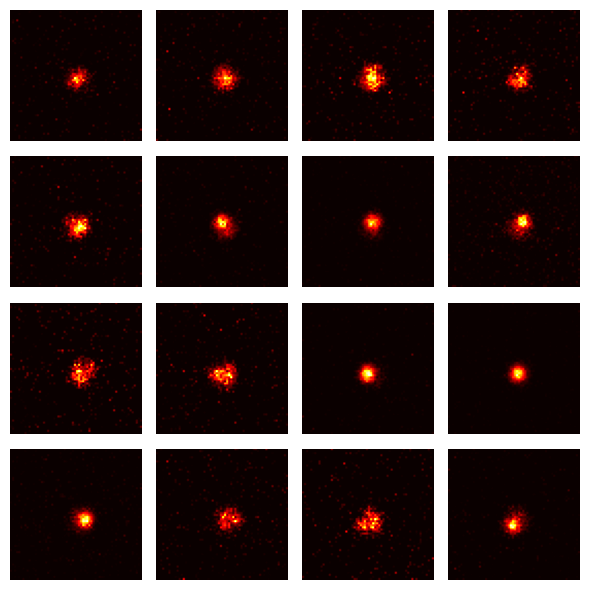

In [17]:
fig_x = gra.ShowDataset(psf_d5[:,:,:],normalize = False, colorbar=False)

### Deconvolve

if out='all' the result is a stack of the iterations, select img_deconv[-1,x,y]. If out='last',it gives only the final iteration [x,y]

In [18]:
print(datacut.shape)
print(psf_d7.shape)

(64, 64, 48)
(64, 64, 48)


Multi-image deconvolution:


100%|██████████| 10/10 [00:00<00:00, 12.23it/s]


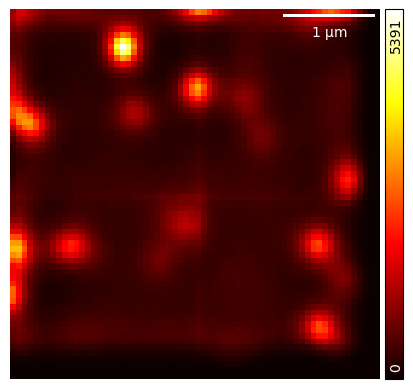

In [19]:
#classical deconvolutin
img_deconv = dec.MultiImg_RL_FFT(psf_d7, datacut, max_iter = 10, reg=0, out='all') #all or last
gra.ShowImg(img_deconv[-1,...], pxsize_x = pxsizex)
plt.show()

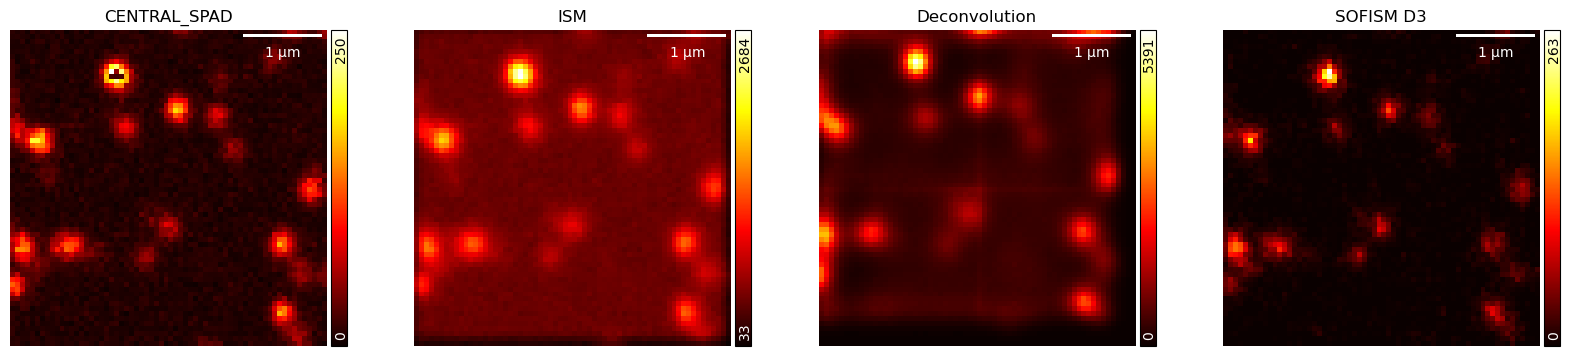

In [21]:
fig, ax = plt.subplots(1, 4, figsize=(20,20))
gra.ShowImg(CENTRAL_SPAD, pxsize_x = pxsizex, fig = fig, ax = ax[0])
ax[0].set_title('CENTRAL_SPAD')
gra.ShowImg(ISM_D7, pxsize_x = pxsizex, fig = fig, ax = ax[1])
ax[1].set_title('ISM')
gra.ShowImg(img_deconv[-1,:,:], pxsize_x = pxsizex, fig = fig, ax = ax[2])
ax[2].set_title('Deconvolution')
gra.ShowImg(SOFISM_D3, pxsize_x = pxsizex, fig = fig, ax = ax[3])
ax[3].set_title('SOFISM D3')
plt.show()

In [23]:
#Save all iterations
# tiff.imwrite(savename + ' deconv all-iter.tiff', img_deconv[-1,:,:])

In [25]:
# im = Image.fromarray(img_deconv[-1,...])
# im.save(savename + ' deconv d3.tiff')

## Results

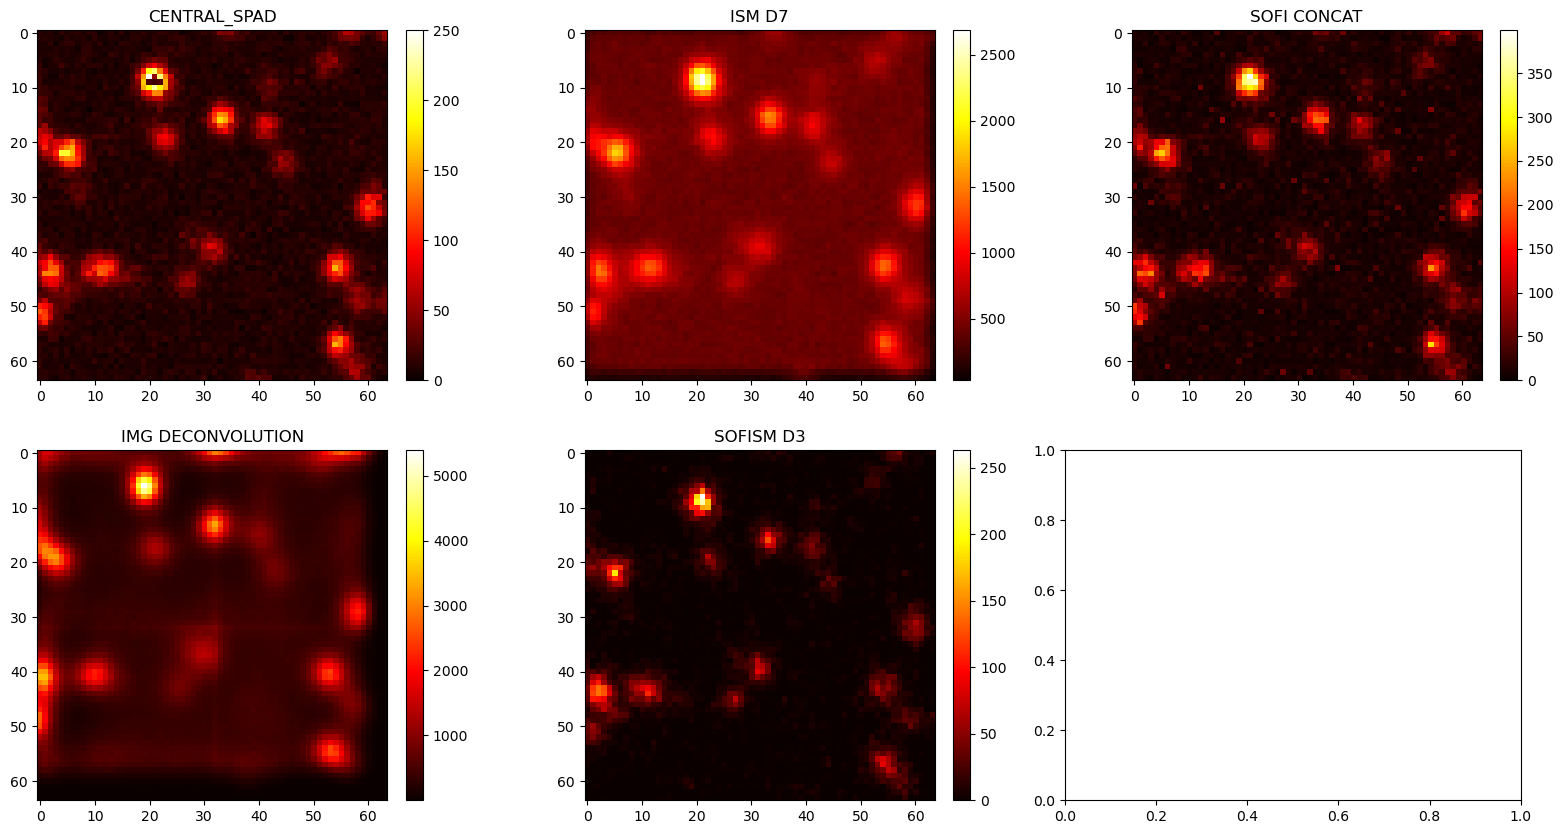

In [26]:
fig, ax = plt.subplots(2,3, figsize=(20,10))
plt.subplots_adjust(hspace=0.2)

ax1 = ax[0,0].imshow(CENTRAL_SPAD, cmap='hot')
ax[0,0].set_title('CENTRAL_SPAD')
fig.colorbar(ax1,fraction=0.046, pad=0.04)

ax2=ax[0,1].imshow(ISM_D7, cmap='hot')
ax[0,1].set_title('ISM D7')
fig.colorbar(ax2,fraction=0.046, pad=0.04)

ax3=ax[0,2].imshow(SOFI_CONCAT[:,:,0], cmap='hot')#img_deconv[-1,300:450,0:150]) 
ax[0,2].set_title('SOFI CONCAT')
fig.colorbar(ax3,fraction=0.046, pad=0.04)

ax4=ax[1,0].imshow(img_deconv[-1,...], cmap='hot')
ax[1,0].set_title('IMG DECONVOLUTION')
fig.colorbar(ax4,fraction=0.046, pad=0.04)

ax5=ax[1,1].imshow(SOFISM_D3, cmap='hot')
ax[1,1].set_title('SOFISM D3')
fig.colorbar(ax5,fraction=0.046, pad=0.04)

plt.show()

# ax6=ax[1,2].imshow(np.sum(central,axis=(0,3)))
# ax[1,2].set_title('central element')
# fig.colorbar(ax6,fraction=0.046, pad=0.04)

# Resolution measurement

In [ ]:
img_1 = CENTRAL_SPAD/np.max(CENTRAL_SPAD) #img_sum#np.sum(data,axis=(0,1,4))[:,:,24]#img_deconv[-1,...] #insert here the images 1 and 2 that you want to analyse
img_2 = SOFISM_D3/np.max(SOFISM_D3) #img_ism_sum#srrf_ism_1[...]

In [ ]:
#img_1=tifffile.imread("C:/Users/rbolz/Downloads/qdots confocal repsum.tif")
#img_2=img_deconv[-1,...]

## Find peaks

In [ ]:
xc=peak_local_max(img_1,min_distance=4, threshold_abs=0.3) # cordinates peaks
maxvalues = np.array([img_1[xc[i,0],xc[i,1]] for i in range(xc.shape[0])])

xc1 = xc # for filters like grater than less than ....

In [ ]:
ROIsizeC = 10
Npart = xc1.shape[0]
fig, ax = plt.subplots(1, 2, figsize=(15,15))

ax[0].imshow(img_1,cmap='hot')#, vmax=300)
#ax[0].scatter(xc1[:,1],xc1[:,0])
ax[0].set_title('Confocal')
for l in range(Npart):
    rect = Rectangle((xc1[l,1]-ROIsizeC/2,xc1[l,0]-ROIsizeC/2),ROIsizeC,ROIsizeC,linewidth=1,edgecolor='w',facecolor='none')
    ax[0].add_patch(rect)
    ax[0].text(xc1[l,1]+4+ROIsizeC/2, xc1[l,0], l, fontsize=14, color='green')
    
ax[1].imshow(img_2,cmap='hot')#, vmax=50)
ax[1].set_title('ISM')
for l in range(Npart):
    rect = Rectangle((xc1[l,1]-ROIsizeC/2,xc1[l,0]-ROIsizeC/2),ROIsizeC,ROIsizeC,linewidth=1,edgecolor='w',facecolor='none')
    ax[1].add_patch(rect)
    ax[1].text(xc1[l,1]+4+ROIsizeC/2, xc1[l,0], l, fontsize=14, color='white')   
ax = plt.gca()

In [ ]:
# Remove specific particles
#Refresh the image above to see the updated indexes after every deletion!

wh = img_1.shape[0] # image height and width
halfsize = ROIsizeC / 2

# remove elements from borders
mask = (
    ((xc1 + (halfsize, halfsize)) < wh).all(axis=1) &
    ((xc1 - (halfsize, halfsize)) >= 0).all(axis=1)
)

xc1 = xc1[mask]
Npart = xc1.shape[0]

## Particle Fit

In [ ]:
def erfC(x, amp, xc, w, offset):
    fitfunction=amp*w*w*np.pi*(1-scipy.special.erf((xc-x)/(np.sqrt(2.0)*w)))+offset*ROIsizeC*x
    return fitfunction

In [ ]:
magn=1
res_conf=np.zeros((Npart,3))
res_ism=np.zeros((Npart,3))
integrali_conf=np.zeros((Npart,ROIsizeC,2))
integrali_ism=np.zeros((Npart,ROIsizeC,2))

for l in range(0,Npart,1): #inizia il loop sulle particelle
    
    ROItemp_conf=np.zeros((ROIsizeC,ROIsizeC),dtype='float')
    ROItemp_ism=np.zeros((ROIsizeC,ROIsizeC),dtype='float')
    yi= (xc1[l,1]-ROIsizeC/2).astype(int)
    yf= (xc1[l,1]+ROIsizeC/2).astype(int)
    xi= (xc1[l,0]-ROIsizeC/2).astype(int)
    xf= (xc1[l,0]+ROIsizeC/2).astype(int)
    
    for i in range(xi,xf,1): #crea la ROI attorno alla NP
        for j in range(yi,yf,1):
            ROItemp_conf[i-xi][j-yi]=img_1[i][j]
            ROItemp_ism[i-xi][j-yi]=img_2[i][j]
    #plt.imshow(ROItemp_conf.T)
    
    integral_conf=np.zeros(ROIsizeC+1,dtype='float')
    integral_ism=np.zeros(ROIsizeC+1,dtype='float')
    axisC=np.zeros(ROIsizeC+1,dtype='float')
    
    for i in range(ROIsizeC+1):
        axisC[i]=i
        
    for i in range(ROIsizeC):   
        for j in range(ROIsizeC):
            integral_conf[i]=integral_conf[i]+ROItemp_conf[j][i]
            integral_ism[i]=integral_ism[i]+ROItemp_ism[j][i]
        integral_conf[i+1]=integral_conf[i]
        integral_ism[i+1]=integral_ism[i]
            
    popt1, pcov1 = curve_fit(erfC, axisC, integral_conf, bounds=(0,np.inf), p0=(1005,5,2,10))
    popt2, pcov2 = curve_fit(erfC, axisC, integral_ism, bounds=(0,np.inf), p0=(1005,5,2,10))
    
    res_conf[l,0]=res_ism[l,0]=l
    res_conf[l,1]=popt1[2]*pxsizex*2.35/magn
    res_ism[l,1]=popt2[2]*pxsizex*2.35/magn
    res_conf[l,2]=popt1[0]
    res_ism[l,2]=popt2[0]
    
    
    for i in range(ROIsizeC):
        integrali_conf[l,i,0]=integral_conf[i]
        integrali_conf[l,i,1]=erfC(axisC,*popt1)[i]
        integrali_ism[l,i,0]=integral_ism[i]
        integrali_ism[l,i,1]=erfC(axisC,*popt2)[i]

print('CENTRAL SPAD Avg FWHM: \n' + str(np.round(np.mean(res_conf[:,1]),5)) + '±' + str(np.round(np.std(res_conf[:,1]))) + '\n\nSOFIISM Avg FWHM: \n' + str(np.round(np.mean(res_ism[:,1]),5)) + ' +- ' + str(np.round(np.std(res_ism[:,1]))))
print('\nCENTRAL SPAD Intensity: \n' + str(np.round(np.mean(res_conf[:,2]),2)) + '±' + str(np.round(np.std(res_conf[:,2]))) + '\n\nSOFISM Intensity: \n' + str(np.round(np.mean(res_ism[:,2]),2)) + ' +- ' + str(np.round(np.std(res_ism[:,2]))))

In [ ]:
print( 'Confocal results: \n' + str(res_conf) + '\n\n ISM results: \n' + str(res_ism))

In [ ]:
plt.plot(integrali_ism[1,:,0],marker='o')
plt.plot(integrali_ism[1,:,1],linestyle='dashed')
plt.tick_params(axis='both', direction= 'in')

## PROVE CORRELAZIONI

In [ ]:
print(d3.shape)

In [ ]:
#Definisco sequenza intensità ISM

ttrace_ism = np.zeros((3,512,512,50,9))

for i in tqdm(range(50)):
    ttrace_ism[0,:,:,i,:]=apr.Reassignment(shift3,d3[0,:,:,i,:])
    ttrace_ism[1,:,:,i,:]=apr.Reassignment(shift3,d3[1,:,:,i,:])
    ttrace_ism[2,:,:,i,:]=apr.Reassignment(shift3,d3[2,:,:,i,:])
ttrace_ism_sum=np.sum(ttrace_ism, axis=(-1))
print(ttrace_ism_sum.shape)

In [ ]:
plt.plot(ttrace_ism_sum[0,440,332,:])

In [ ]:
#SRRF sulla sequenza di intensità
srrf_ism_2_var = np.zeros((3,512,512))
srrf_ism_2_avg = np.zeros((3,512,512))
srrf_ism_2_tac = np.zeros((3,512,512))

for f in range(3):
    srrf_ism_sum_2= eSRRF(np.ascontiguousarray(np.transpose(ttrace_ism_sum[f,:,:,:],axes=(2,0,1))), magnification=1,radius=7)[0]
    srrf_ism_2_var[f,...] = calculate_eSRRF_temporal_correlations(srrf_ism_sum_2, 'VAR')
    srrf_ism_2_avg[f,...] = calculate_eSRRF_temporal_correlations(srrf_ism_sum_2, 'AVG')
    srrf_ism_2_tac[f,...] = calculate_eSRRF_temporal_correlations(srrf_ism_sum_2, 'TAC2')

In [ ]:
print(srrf_ism_2_tac.shape)

In [ ]:
srrf_ism_2_var_mean = np.mean(srrf_ism_2_var, axis=0)
srrf_ism_2_avg_mean = np.mean(srrf_ism_2_avg, axis=0)
srrf_ism_2_tac_mean = np.abs(np.mean(srrf_ism_2_tac, axis=0))

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(10,10))
ax0 = ax[0].imshow(srrf_ism_2_avg_mean[430:455, 320:345])
ax[0].set_title('average')
ax1= ax[1].imshow(srrf_ism_2_var_mean[430:455, 320:345])
ax[1].set_title('Variance')
ax2 = ax[2].imshow(srrf_ism_2_tac_mean[430:455, 320:345])
ax[2].set_title('Autocorr.')
print(srrf_ism_sum_2.shape)

In [ ]:
def correla(t1,tau):
    corr_carota=0
    t1_b = t1 - np.mean(t1)
    
    for i in range(t1.shape[0]-tau):
        corr_carota += t1_b[i]*t1_b[i+tau]
    corr_carota /= t1.shape[0]-tau
    corr_carota /= np.mean(t1)**2
    return corr_carota

In [ ]:
img_autocorr=np.zeros((512,512,2))
for i in tqdm(range(srrf_ism_sum_2.shape[1])):
    for j in range(srrf_ism_sum_2.shape[2]):
        for tau in range(2):
            img_autocorr[i,j,tau] = correla(srrf_ism_sum_2[:,i,j],tau)

In [ ]:
plt.imshow(img_autocorr[:,:,1])

In [ ]:
#Correlazioni definite da noi

srrf_carota = srrf_ism_sum_2[:,441,334]
srrf_carota_delta = srrf_carota - np.mean(srrf_carota)
corr_carota=0

for i in range(srrf_carota.shape[0]-1):
    corr_carota += srrf_carota_delta[i]*srrf_carota_delta[i+1]
corr_carota /= srrf_carota.shape[0]-1
#corr_carota /= np.mean(srrf_carota)**2

print(corr_carota)
print(srrf_ism_2[441,334])

In [ ]:
#Correlazioni con Scipy

test2 = np.zeros((ttrace_ism_sum.shape[0],ttrace_ism_sum.shape[1],ttrace_ism_sum.shape[2]))

for i in range(d3.shape[1]):
    for j in range(d3.shape[2]):
        m4 = np.mean(ttrace_ism_sum[i,j,:])
        test2[i,j,:] = scipy.signal.correlate(ttrace_ism_sum[i,j,:]-m4,ttrace_ism_sum[i,j,:]-m4, method='auto', mode='same')
        if m4==0: m4=1
        test2[i,j,:] /= m4**2
plt.imshow(test2[430:455, 320:345,:].sum(axis=2))
plt.colorbar()

In [ ]:
plt.plot(test2[440,:,:].sum(axis=1))

In [ ]:
## Temporal correlations su ISS

def correlazione(t1,m1,t2,m2):
    fft1=scipy.fftpack.fft([(t1[i])-m1 for i in range(len(t1))])
    fft2=scipy.fftpack.fft([(t2[i])-m2 for i in range(len(t2))])
    fft1=np.ma.conjugate(fft1)
    crosscorr=np.real(scipy.fftpack.ifft(fft1*fft2))#/(m1*m2*len(t1)))
    return crosscorr

central=tifffile.imread('/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Margaux/ISS ISM/2025 07 07-08 Qdots/Qdots_FOV5um_64x64_5msPixel_23rip_37mW.tif')
#central=central[:23,:,:]
plt.imshow(central[10,:,:])
print(central.shape)

img_autocorr=np.zeros((central.shape[1],central.shape[2],central.shape[0]), dtype='float')
print(img_autocorr.shape)

for i in range(central.shape[1]):
    for j in range(central.shape[2]):
        count=0
        if np.mean(central[:,i,j])!=0:
                count=count+1
                img_autocorr[i,j,:]=img_autocorr[i,j,:]+correlazione(central[:,i,j],np.mean(central[:,i,j]),central[:,i,j],np.mean(central[:,i,j]))
        if count!=0:
            img_autocorr[i,j,:]=img_autocorr[i,j,:]/count
plt.imshow(img_autocorr[:,:,0])            
plt.colorbar()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
gra.ShowImg(central[0,:,:], pxsize_x = pxsizex, fig = fig, ax = ax[0])
ax[0].set_title('ISM + spatial srrf')
gra.ShowImg(img_autocorr[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[1])
#gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1],color='red',labels=False)
ax[1].set_title('ISM + time srrf')

In [ ]:
plt.plot(np.arange(0,100,1),img_autocorr[41,28,:100])